# SVM Model — XLE Next-Day Direction Prediction

In [ ]:
%pip install -r ../requirements.txt

In [44]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import loguniform, randint
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 1. Load Data

In [45]:
X_train = pd.read_csv("data/X_train(2016-2023).csv", index_col=0)
X_val   = pd.read_csv("data/X_val(2024).csv",    index_col=0)
X_test  = pd.read_csv("data/X_test(2025).csv",   index_col=0)

y_train = pd.read_csv("data/y_train(2016-2023).csv", index_col=0).squeeze()
y_val   = pd.read_csv("data/y_val(2024).csv",    index_col=0).squeeze()
y_test  = pd.read_csv("data/y_test(2025).csv",   index_col=0).squeeze()

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"\nTarget distribution (train):\n{y_train.value_counts(normalize=True).round(3)}")

Train: (2012, 174), Val: (252, 174), Test: (249, 174)

Target distribution (train):
Target_Next_Day_Direction
1.0    0.513
0.0    0.487
Name: proportion, dtype: float64


## 2. Feature Engineering


In [ ]:
MACRO_COLS = [
    "VIX_Fear_Index_Log_Return", "Oil_Volatility_Log_Return",
    "Crude_Oil_Futures_Log_Return", "Natural_Gas_Futures_Log_Return",
    "US_Dollar_Index_DXY_Log_Return", "SP500_Futures_Log_Return",
    "Nikkei_225_Log_Return", "FTSE_100_Log_Return",
]
STOCK_COLS = [c for c in X_train.columns if c not in MACRO_COLS]

def engineer_features(X, fit_stats=None):
    """lag features, rolling stats, and sector aggregates."""
    df = X.copy()

    # Sector aggregate: mean and std of all energy stock returns
    df["sector_mean_return"] = df[STOCK_COLS].mean(axis=1)
    df["sector_std_return"] = df[STOCK_COLS].std(axis=1)
    df["sector_positive_pct"] = (df[STOCK_COLS] > 0).mean(axis=1)

    # Key features to create lags/rolling stats for
    key_features = MACRO_COLS + ["sector_mean_return"]

    for col in key_features:
        # Lag features (1-day, 2-day, 5-day)
        for lag in [1, 2, 5]:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)
        # Rolling 5-day mean and std
        df[f"{col}_roll5_mean"] = df[col].rolling(5).mean()
        df[f"{col}_roll5_std"] = df[col].rolling(5).std()
        # Rolling 20-day mean
        df[f"{col}_roll20_mean"] = df[col].rolling(20).mean()

    # Drop rows with NaN from lagging/rolling
    df = df.dropna()

    # Drop individual stock columns — keep sector aggregates instead
    df = df.drop(columns=STOCK_COLS)

    # Re-standardize new features
    if fit_stats is None:
        means = df.mean()
        stds = df.std().replace(0, 1)
        fit_stats = (means, stds)
    else:
        means, stds = fit_stats

    df = (df - means) / stds
    return df, fit_stats

X_train_eng, stats = engineer_features(X_train)
X_val_eng, _ = engineer_features(X_val, fit_stats=stats)
X_test_eng, _ = engineer_features(X_test, fit_stats=stats)

# Align y with the trimmed X (dropped first 20 rows due to rolling)
y_train_eng = y_train.loc[X_train_eng.index]
y_val_eng = y_val.loc[X_val_eng.index]
y_test_eng = y_test.loc[X_test_eng.index]

print(f"Engineered features: {X_train_eng.shape[1]}")
print(f"Train: {X_train_eng.shape}, Val: {X_val_eng.shape}, Test: {X_test_eng.shape}")
print(f"\nSample feature names:\n{list(X_train_eng.columns[:15])}")

Engineered features: 65
Train: (1993, 65), Val: (233, 65), Test: (230, 65)

Sample feature names:
['VIX_Fear_Index_Log_Return', 'Oil_Volatility_Log_Return', 'Crude_Oil_Futures_Log_Return', 'Natural_Gas_Futures_Log_Return', 'US_Dollar_Index_DXY_Log_Return', 'SP500_Futures_Log_Return', 'Nikkei_225_Log_Return', 'FTSE_100_Log_Return', 'sector_mean_return', 'sector_std_return', 'sector_positive_pct', 'VIX_Fear_Index_Log_Return_lag1', 'VIX_Fear_Index_Log_Return_lag2', 'VIX_Fear_Index_Log_Return_lag5', 'VIX_Fear_Index_Log_Return_roll5_mean']


## 3. PCA Dimensionality Reduction

Reduce the engineered feature set further with PCA to remove multicollinearity and noise.

PCA: 65 features → 46 components (95% variance)
Explained variance per component:
[0.15  0.069 0.055 0.051 0.045 0.036 0.034 0.032 0.028 0.025]


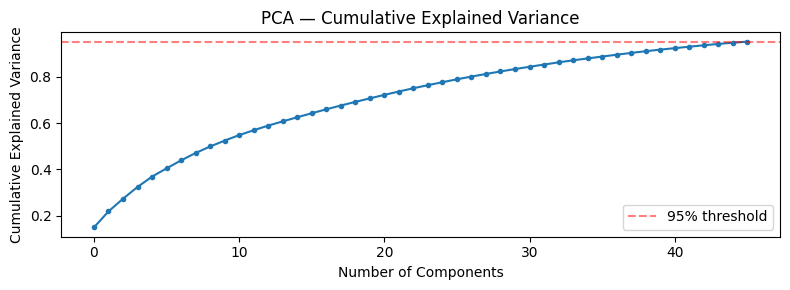

In [47]:
pca = PCA(n_components=0.95, random_state=42)  # keep 95% variance
X_train_pca = pca.fit_transform(X_train_eng)
X_val_pca = pca.transform(X_val_eng)
X_test_pca = pca.transform(X_test_eng)

print(f"PCA: {X_train_eng.shape[1]} features → {X_train_pca.shape[1]} components (95% variance)")
print(f"Explained variance per component:\n{np.round(pca.explained_variance_ratio_[:10], 3)}")

# Plot cumulative explained variance
plt.figure(figsize=(8, 3))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o", markersize=3)
plt.axhline(0.95, color="r", linestyle="--", alpha=0.5, label="95% threshold")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Baseline SVM (Default RBF on PCA Features)

In [48]:
svm_base = SVC(kernel="rbf", random_state=42, probability=True)
svm_base.fit(X_train_pca, y_train_eng)

y_val_pred = svm_base.predict(X_val_pca)
y_val_prob = svm_base.predict_proba(X_val_pca)[:, 1]

print("Baseline SVM (PCA features) — Validation Set")
print(f"Accuracy:  {accuracy_score(y_val_eng, y_val_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val_eng, y_val_prob):.4f}")
print(f"\n{classification_report(y_val_eng, y_val_pred, target_names=['Down/Flat', 'Up'])}")

Baseline SVM (PCA features) — Validation Set
Accuracy:  0.6309
ROC-AUC:   0.3520

              precision    recall  f1-score   support

   Down/Flat       0.60      0.56      0.58       106
          Up       0.65      0.69      0.67       127

    accuracy                           0.63       233
   macro avg       0.63      0.62      0.63       233
weighted avg       0.63      0.63      0.63       233



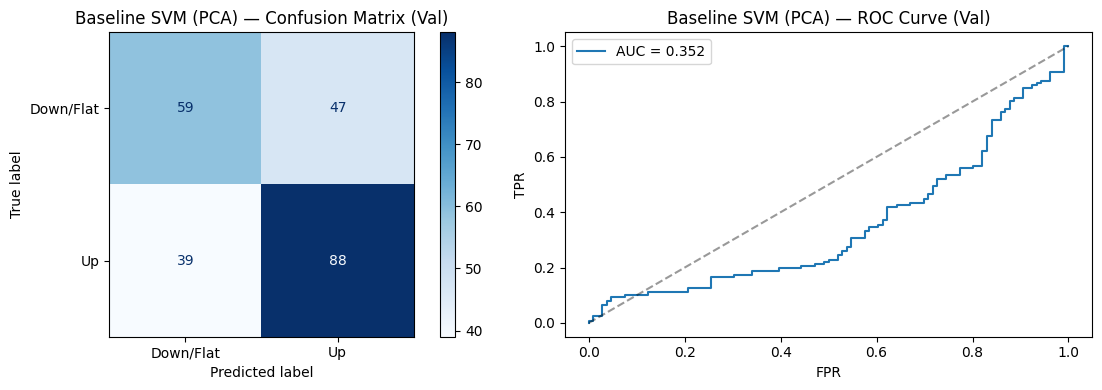

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_val_eng, y_val_pred, display_labels=["Down/Flat", "Up"], ax=axes[0], cmap="Blues"
)
axes[0].set_title("Baseline SVM (PCA) — Confusion Matrix (Val)")

fpr, tpr, _ = roc_curve(y_val_eng, y_val_prob)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_val_eng, y_val_prob):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set(xlabel="FPR", ylabel="TPR", title="Baseline SVM (PCA) — ROC Curve (Val)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning (RandomizedSearchCV)

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    "kernel": ["rbf", "linear", "poly"],
    "C": loguniform(0.01, 100),
    "gamma": loguniform(1e-4, 1),
    "degree": randint(2, 4),
}

random_search = RandomizedSearchCV(
    SVC(random_state=42), 
    param_dist,
    n_iter=40,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True,
)

random_search.fit(X_train_pca, y_train_eng)

print(f"\nBest params: {random_search.best_params_}")
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")

# Show top 10 configurations
results_df = pd.DataFrame(random_search.cv_results_).sort_values("rank_test_score")
print("\nTop 10 configurations:")
print(results_df[["params", "mean_test_score", "std_test_score", "rank_test_score"]].head(10).to_string())

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params: {'C': np.float64(2.754143921332031), 'degree': 3, 'gamma': np.float64(0.00013726318898045882), 'kernel': 'linear'}
Best CV ROC-AUC: 0.5107

Top 10 configurations:
                                                                                         params  mean_test_score  std_test_score  rank_test_score
12   {'C': 2.754143921332031, 'degree': 3, 'gamma': 0.00013726318898045882, 'kernel': 'linear'}         0.510675        0.034205                1
10    {'C': 72.86653737491046, 'degree': 3, 'gamma': 0.0034806953267852736, 'kernel': 'linear'}         0.509077        0.036249                2
28   {'C': 11.044350847124697, 'degree': 3, 'gamma': 0.0008789004341405484, 'kernel': 'linear'}         0.508324        0.035768                3
23      {'C': 12.164139351417068, 'degree': 2, 'gamma': 0.5072283440670037, 'kernel': 'linear'}         0.508091        0.035937                4
29     {'C': 0.9444574254983568

## 6. Evaluate Tuned Model on Validation Set

In [51]:
# Refit best model WITH probability=True for ROC curves
best_params = random_search.best_params_
svm_tuned = SVC(**best_params, random_state=42, probability=True)
svm_tuned.fit(X_train_pca, y_train_eng)

y_val_pred_tuned = svm_tuned.predict(X_val_pca)
y_val_prob_tuned = svm_tuned.predict_proba(X_val_pca)[:, 1]

print("Tuned SVM — Validation Set")
print(f"Accuracy:  {accuracy_score(y_val_eng, y_val_pred_tuned):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val_eng, y_val_prob_tuned):.4f}")
print(f"\n{classification_report(y_val_eng, y_val_pred_tuned, target_names=['Down/Flat', 'Up'])}")

Tuned SVM — Validation Set
Accuracy:  0.5751
ROC-AUC:   0.5867

              precision    recall  f1-score   support

   Down/Flat       0.54      0.45      0.49       106
          Up       0.60      0.68      0.63       127

    accuracy                           0.58       233
   macro avg       0.57      0.56      0.56       233
weighted avg       0.57      0.58      0.57       233



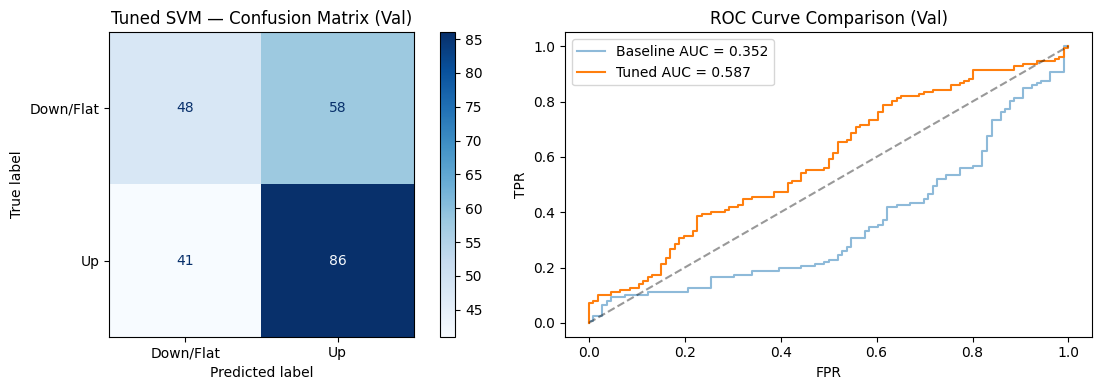

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_val_eng, y_val_pred_tuned, display_labels=["Down/Flat", "Up"], ax=axes[0], cmap="Blues"
)
axes[0].set_title("Tuned SVM — Confusion Matrix (Val)")

fpr_t, tpr_t, _ = roc_curve(y_val_eng, y_val_prob_tuned)
axes[1].plot(fpr, tpr, label=f"Baseline AUC = {roc_auc_score(y_val_eng, y_val_prob):.3f}", alpha=0.5)
axes[1].plot(fpr_t, tpr_t, label=f"Tuned AUC = {roc_auc_score(y_val_eng, y_val_prob_tuned):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set(xlabel="FPR", ylabel="TPR", title="ROC Curve Comparison (Val)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Final Evaluation on Test Set

In [53]:
y_test_pred = svm_tuned.predict(X_test_pca)
y_test_prob = svm_tuned.predict_proba(X_test_pca)[:, 1]

print("=== Tuned SVM — Test Set ===")
print(f"Accuracy:  {accuracy_score(y_test_eng, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_eng, y_test_prob):.4f}")
print(f"\n{classification_report(y_test_eng, y_test_pred, target_names=['Down/Flat', 'Up'])}")

=== Tuned SVM — Test Set ===
Accuracy:  0.5174
ROC-AUC:   0.4997

              precision    recall  f1-score   support

   Down/Flat       0.44      0.35      0.39       102
          Up       0.56      0.65      0.60       128

    accuracy                           0.52       230
   macro avg       0.50      0.50      0.50       230
weighted avg       0.51      0.52      0.51       230



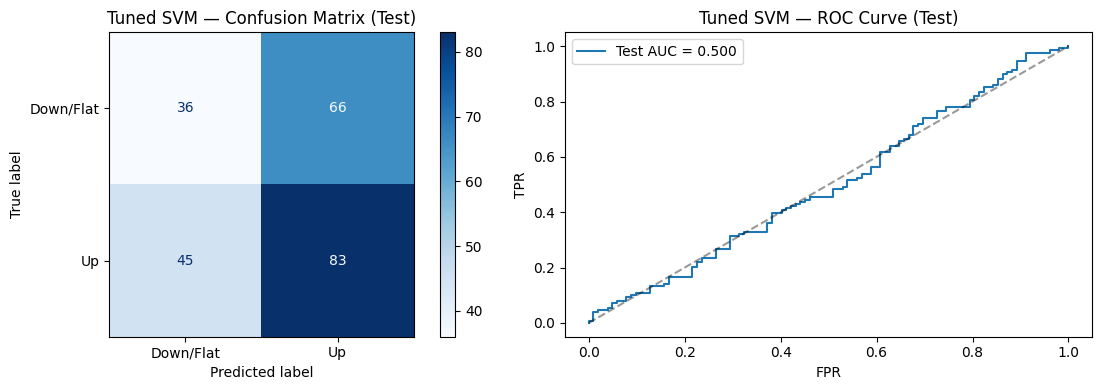

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test_eng, y_test_pred, display_labels=["Down/Flat", "Up"], ax=axes[0], cmap="Blues"
)
axes[0].set_title("Tuned SVM — Confusion Matrix (Test)")

fpr_test, tpr_test, _ = roc_curve(y_test_eng, y_test_prob)
axes[1].plot(fpr_test, tpr_test, label=f"Test AUC = {roc_auc_score(y_test_eng, y_test_prob):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set(xlabel="FPR", ylabel="TPR", title="Tuned SVM — ROC Curve (Test)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Summary Comparison

In [ ]:
summary = pd.DataFrame({
    "Model": ["Baseline SVM (PCA)", "Tuned SVM (PCA)"],
    "Val Accuracy": [
        accuracy_score(y_val_eng, y_val_pred),
        accuracy_score(y_val_eng, y_val_pred_tuned),
    ],
    "Val ROC-AUC": [
        roc_auc_score(y_val_eng, y_val_prob),
        roc_auc_score(y_val_eng, y_val_prob_tuned),
    ],
    "Test Accuracy": [
        "—",
        f"{accuracy_score(y_test_eng, y_test_pred):.4f}",
    ],
    "Test ROC-AUC": [
        "—",
        f"{roc_auc_score(y_test_eng, y_test_prob):.4f}",
    ],
}).set_index("Model")

print(f"Best hyperparameters: {random_search.best_params_}")
print(f"PCA components: {X_train_pca.shape[1]}")
print(f"Engineered features: {X_train_eng.shape[1]}\n")
summary

Best hyperparameters: {'C': np.float64(2.754143921332031), 'degree': 3, 'gamma': np.float64(0.00013726318898045882), 'kernel': 'linear'}
PCA components: 46
Engineered features: 65



,Val Accuracy,Val ROC-AUC,Test Accuracy,Test ROC-AUC
Model,,,,
Baseline SVM (PCA),0.630901,0.351954,—,—
Tuned SVM (PCA),0.575107,0.586688,0.5174,0.4997


## 9. Sensitivity Analysis

Vary the decision threshold of the hypertuned model and observe the effect on F1 Score, Precision, Recall, and Accuracy.

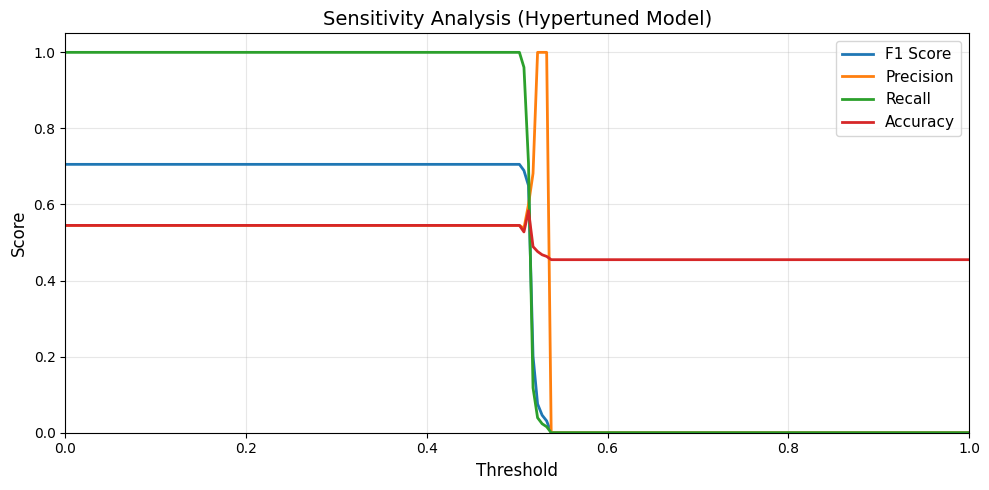

Optimal threshold (max F1): 0.000
  F1:        0.7056
  Precision: 0.5451
  Recall:    1.0000
  Accuracy:  0.5451


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.linspace(0, 1, 200)

f1_scores = []
precisions = []
recalls = []
accuracies = []

y_val_prob_tuned_arr = np.array(y_val_prob_tuned)

for t in thresholds:
    y_pred_t = (y_val_prob_tuned_arr >= t).astype(int)
    f1_scores.append(f1_score(y_val_eng, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_val_eng, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_val_eng, y_pred_t, zero_division=0))
    accuracies.append(accuracy_score(y_val_eng, y_pred_t))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores, label="F1 Score", linewidth=2)
ax.plot(thresholds, precisions, label="Precision", linewidth=2)
ax.plot(thresholds, recalls, label="Recall", linewidth=2)
ax.plot(thresholds, accuracies, label="Accuracy", linewidth=2)

ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Sensitivity Analysis (Hypertuned Model)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
fig.tight_layout()
plt.show()

# Print optimal threshold by F1
best_idx = np.argmax(f1_scores)
print(f"Optimal threshold (max F1): {thresholds[best_idx]:.3f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall:    {recalls[best_idx]:.4f}")
print(f"  Accuracy:  {accuracies[best_idx]:.4f}")